# Decision Intelligence Assistant — EDA
## Dataset: Customer Support on Twitter

In [32]:
import pandas as pd
df = pd.read_csv('../data/raw/twcs.csv')
print(df.shape)
print(df.head())

(2811774, 7)
   tweet_id   author_id  inbound                      created_at  \
0         1  sprintcare    False  Tue Oct 31 22:10:47 +0000 2017   
1         2      115712     True  Tue Oct 31 22:11:45 +0000 2017   
2         3      115712     True  Tue Oct 31 22:08:27 +0000 2017   
3         4  sprintcare    False  Tue Oct 31 21:54:49 +0000 2017   
4         5      115712     True  Tue Oct 31 21:49:35 +0000 2017   

                                                text response_tweet_id  \
0  @115712 I understand. I would like to assist y...                 2   
1      @sprintcare and how do you propose we do that               NaN   
2  @sprintcare I have sent several private messag...                 1   
3  @115712 Please send us a Private Message so th...                 3   
4                                 @sprintcare I did.                 4   

   in_response_to_tweet_id  
0                      3.0  
1                      1.0  
2                      4.0  
3                

In [33]:
print(df['inbound'].value_counts())

inbound
True     1537843
False    1273931
Name: count, dtype: int64


In [34]:
print(df[df['inbound']==False]['author_id'].nunique())

108


## 1. Filter Customer Tweets & Sample

In [35]:
customer_tweets= df[df['inbound']==True]
sample = customer_tweets.sample(200000, random_state=42)
sample = sample.reset_index(drop=True)
print(sample.shape)

(200000, 7)


## 2. Basic Dataset Overview

In [36]:
print(sample.info())
print('\n')
print(sample['text'].head(10))

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   tweet_id                 200000 non-null  int64  
 1   author_id                200000 non-null  str    
 2   inbound                  200000 non-null  bool   
 3   created_at               200000 non-null  str    
 4   text                     200000 non-null  str    
 5   response_tweet_id        169571 non-null  str    
 6   in_response_to_tweet_id  97804 non-null   float64
dtypes: bool(1), float64(1), int64(1), str(4)
memory usage: 9.3 MB
None


0    @AppleSupport Basically for a chat to be opene...
1    @AppleSupport iOS 11.02 and Watchos4.0: No ico...
2    Dear god not again,@AppleSupport https://t.co/...
3    @ATVIAssist Hi there! If I buy Call of Duty WW...
4    Hi @Safaricom_Care why can't I pay my my Dstv ...
5    trying to buy my kid nibling a keyboard for an...
6 

## 3. Text Preprocessing

In [37]:

import re
import html
 
def clean_text(text):
    # converts &amp; → & , &lt; → < etc.
    text = html.unescape(text) 
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags
    text = re.sub(r'#\w+', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    #lowercase
    text = text.lower()
    return text
sample['cleaned_text'] = sample['text'].apply(clean_text)
print(sample['cleaned_text'].head(10))

sample = sample[sample['cleaned_text'].str.split().str.len() >= 5]
print(f"After removing short tweets: {sample.shape}")


0    basically for a chat to be opened from call lo...
1    ios 11.02 and watchos4.0: no icon for twitter ...
2                                  dear god not again,
3    hi there! if i buy call of duty wwii on steam ...
4    hi why can't i pay my my dstv texts says the o...
5    trying to buy my kid nibling a keyboard for an...
6                                                     
7    recibi llamadas de celulares 3113552287 y 3114...
8    hi for 2days now i have not being able to make...
9    are you guys having problems with the launch o...
Name: cleaned_text, dtype: str
After removing short tweets: (178161, 8)


In [38]:
from langdetect import detect

def is_english(text):
    try:
        return detect(text) == 'en'
    except:
        return False

sample = sample[sample['cleaned_text'].apply(is_english)]
print(f"After keeping English only: {sample.shape}")

After keeping English only: (168687, 8)


## Summary so far
- Started with 2.8M tweets
- Filtered to inbound (customer) tweets only: 1.5M
- Sampled 200,000 randomly (random_state=42)
- Cleaned text: removed @mentions, URLs, hashtags, extra whitespace, lowercased
- Removed tweets with less than 5 words
- Removed non-English tweets
- Final dataset: 168,712 tweets

## 4. Labeling Function (Weak Supervision)

**Rule:** A tweet is URGENT if it contains service failure keywords, 
time pressure indicators, financial keywords, or frustration signals.
This is weak supervision — the model learns to reproduce this rule, 
not ground truth urgency.

In [39]:
keywords = {
    # Service failure
    "not working", "broken", "down", "failed", "fail", "error", "issue",
    "problem", "bug", "crash", "crashed", "outage", "offline", "unavailable",
    "unable", "cannot", "can't", "wont", "won't", "doesn't", "doesn't work",
    
    # Access/account issues  
    "locked", "blocked", "banned", "suspended", "lost access", "can't login",
    "can't log in", "password", "hacked", "compromised",
    
    # Financial urgency
    "refund", "charged", "overcharged", "stolen", "fraud", "scam",
    "unauthorized", "dispute", "billing", "cancel", "cancellation",
    
    # Time pressure
    "still", "days", "hours", "weeks", "since", "already", "yet",
    "waiting", "asap", "urgent", "immediately", "emergency",
    
    # Service disruption
    "no service", "no signal", "no internet", "no connection", "disconnected",
    "slow", "not loading", "freezing", "frozen", "stuck",
    
    # Emotional frustration
    "terrible", "awful", "horrible", "worst", "unacceptable", "ridiculous",
    "disgusting", "useless", "pathetic", "disappointed", "frustrated",
    "angry", "furious", "fed up", "sick of", "tired of"
}
def labeling_function(text):
    for keyword in keywords:
        if keyword in text:
            return 1
    # Check frustration signals
    if text.count('!') >= 2:
        return 1
    if re.search(r'[A-Z]{3,}', text):
        return 1
        
    return 0
sample['priority'] = sample['cleaned_text'].apply(labeling_function)
print(sample['priority'].value_counts())

priority
0    96880
1    71807
Name: count, dtype: int64


## 5. Improved Labeling — Sentiment-Aware Weak Supervision

### Why sentiment?
Keywords alone miss context. "broken" in "I broke my personal record!" 
is not urgent. Combining keywords with negative sentiment filters out 
these false positives significantly.

In [40]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER
analyzer = SentimentIntensityAnalyzer()

# Compute sentiment for each tweet
# compound score: -1 (very negative) to +1 (very positive)
sample['sentiment'] = sample['cleaned_text'].apply(
    lambda x: analyzer.polarity_scores(x)['compound']
)

print(sample['sentiment'].describe())
print("\nSentiment distribution:")
print(f"Positive (>0.05): {(sample['sentiment'] > 0.05).sum()}")
print(f"Neutral (-0.05 to 0.05): {((sample['sentiment'] >= -0.05) & (sample['sentiment'] <= 0.05)).sum()}")
print(f"Negative (<-0.05): {(sample['sentiment'] < -0.05).sum()}")

count    168687.000000
mean          0.034749
std           0.457873
min          -0.997200
25%          -0.308900
50%           0.000000
75%           0.401900
max           0.999000
Name: sentiment, dtype: float64

Sentiment distribution:
Positive (>0.05): 68257
Neutral (-0.05 to 0.05): 40849
Negative (<-0.05): 59581


URGENT (1) if ANY of these conditions:
  Condition A: Strong problem keyword + negative sentiment (compound < -0.1)
  Condition B: Financial keyword (regardless of sentiment — money issues are always urgent)
  Condition C: Service completely down keyword (regardless of sentiment)
  Condition D: Extreme frustration signal (2+ exclamation marks OR ALL CAPS)

NORMAL (0): everything else

In [41]:
import re
import emoji

# ── KEYWORD SETS ────────────────────────────────────────────────────────────
PROBLEM_KEYWORDS = {
    "not working", "broken", "failed", "fail", "error", "issue",
    "problem", "bug", "crash", "crashed", "outage", "offline",
    "unavailable", "unable", "cannot", "can't", "wont", "won't",
    "locked", "blocked", "banned", "suspended", "lost access",
    "hacked", "compromised", "not loading", "freezing", "frozen",
    "stuck", "terrible", "awful", "horrible", "worst", "unacceptable",
    "ridiculous", "disgusting", "useless", "pathetic", "disappointed",
    "frustrated", "angry", "furious", "fed up", "sick of", "tired of"
}

FINANCIAL_KEYWORDS = {
    "refund", "charged", "overcharged", "stolen", "fraud", "scam",
    "unauthorized", "double charged", "wrong charge"
}

SERVICE_DOWN_KEYWORDS = {
    "no service", "no signal", "no internet", "no connection",
    "disconnected", "complete outage", "totally down", "not available"
}

NEGATIONS = {"not", "never", "no", "fixed", "resolved", "working now"}

INTENSIFIERS = {
    "very", "extremely", "completely", "totally",
    "absolutely", "really", "so", "super"
}

TIME_PRESSURE = {
    "still", "days", "hours", "weeks", "since",
    "already", "yet", "again"
}

URGENT_EMOJIS = {
    ":enraged_face:", ":angry_face:", ":face_with_symbols_on_mouth:",
    ":crying_face:", ":loudly_crying_face:", ":broken_heart:",
    ":fire:", ":sos:", ":warning:", ":red_circle:", ":skull:",
    ":face_screaming_in_fear:", ":weary_face:", ":tired_face:",
    ":disappointed_face:", ":thumbs_down:"
}

In [42]:
# ── HELPER FUNCTIONS ─────────────────────────────────────────────────────────

def is_negated(text, keyword):
    """Check if keyword is preceded by a negation within 3 words"""
    words = text.split()
    for i, word in enumerate(words):
        if keyword in word:
            window = words[max(0, i-3):i]
            if any(neg in window for neg in NEGATIONS):
                return True
    return False

def has_intensified_keyword(text, keywords):
    """Check if an intensifier appears before a keyword"""
    words = text.split()
    for i, word in enumerate(words):
        if word in INTENSIFIERS and i + 1 < len(words):
            next_words = ' '.join(words[i+1:i+4])
            if any(kw in next_words for kw in keywords):
                return True
    return False

def has_repetition(text):
    """Detect repeated words - sign of frustration"""
    return bool(re.search(r'\b(\w+)\b.*\b\1\b.*\b\1\b', text))

def has_urgent_question(text):
    """Detect urgent questions with time pressure"""
    if '?' in text:
        has_problem = any(kw in text for kw in PROBLEM_KEYWORDS)
        has_time = any(tp in text for tp in TIME_PRESSURE)
        return has_problem and has_time
    return False

In [43]:
# ── CONFIDENCE SCORING ───────────────────────────────────────────────────────

def compute_confidence(row):
    text = row['cleaned_text']
    sentiment = row['sentiment']
    original = row['text']
    emoji_text = emoji.demojize(original)
    score = 0
    reasons = []

    # ── Signal 1: Problem keyword + negative sentiment (weight: 2)
    for keyword in PROBLEM_KEYWORDS:
        if keyword in text and not is_negated(text, keyword):
            if sentiment < -0.1:
                score += 2
                reasons.append(f"problem_keyword:'{keyword}'")
                break

    # ── Signal 2: Financial keyword (weight: 3 - always serious)
    for keyword in FINANCIAL_KEYWORDS:
        if keyword in text:
            score += 3
            reasons.append(f"financial:'{keyword}'")
            break

    # ── Signal 3: Service completely down (weight: 3)
    for keyword in SERVICE_DOWN_KEYWORDS:
        if keyword in text:
            score += 3
            reasons.append(f"service_down:'{keyword}'")
            break

    # ── Signal 4: Negative sentiment alone (weight: 1)
    if sentiment < -0.3:
        score += 1
        reasons.append(f"negative_sentiment:{sentiment:.2f}")

    # ── Signal 5: Intensified problem keyword (weight: 1)
    if has_intensified_keyword(text, PROBLEM_KEYWORDS):
        score += 1
        reasons.append("intensified_keyword")

    # ── Signal 6: Exclamation marks + negative sentiment (weight: 1)
    if original.count('!') >= 2 and sentiment < -0.1:
        score += 1
        reasons.append(f"exclamation:{original.count('!')}marks")

    # ── Signal 7: Two consecutive ALL CAPS words (weight: 1)
    if re.search(r'\b[A-Z]{3,}\b\s+\b[A-Z]{3,}\b', original):
        score += 1
        reasons.append("all_caps")

    # ── Signal 8: Urgent emojis (weight: 2)
    for emoji_name in URGENT_EMOJIS:
        if emoji_name in emoji_text:
            score += 2
            reasons.append(f"emoji:{emoji_name}")
            break

    # ── Signal 9: Word repetition (weight: 1)
    if has_repetition(text):
        score += 1
        reasons.append("word_repetition")

    # ── Signal 10: Urgent question with time pressure (weight: 2)
    if has_urgent_question(text):
        score += 2
        reasons.append("urgent_question")

    return score, reasons

In [44]:
# ── APPLY AND THRESHOLD ──────────────────────────────────────────────────────

print("Computing confidence scores... this may take a few minutes")
results = sample.apply(compute_confidence, axis=1)
sample['confidence_score'] = results.apply(lambda x: x[0])
sample['label_reasons'] = results.apply(lambda x: x[1])

# Threshold: score >= 3 = urgent
THRESHOLD = 3
sample['priority'] = (sample['confidence_score'] >= THRESHOLD).astype(int)

print(f"\nLabel distribution:")
print(sample['priority'].value_counts())
print(f"\nUrgent rate: {sample['priority'].mean():.2%}")
print(f"\nConfidence score distribution:")
print(sample['confidence_score'].describe())

Computing confidence scores... this may take a few minutes

Label distribution:
priority
0    144057
1     24630
Name: count, dtype: int64

Urgent rate: 14.60%

Confidence score distribution:
count    168687.000000
mean          0.872569
std           1.341892
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          12.000000
Name: confidence_score, dtype: float64


In [45]:
print("=== URGENT SAMPLES WITH REASONS ===")
urgent = sample[sample['priority']==1][['cleaned_text','confidence_score','label_reasons']].sample(10, random_state=42)
for _, row in urgent.iterrows():
    print(f"Tweet: {row['cleaned_text'][:100]}")
    print(f"Score: {row['confidence_score']} | Reasons: {row['label_reasons']}")
    print()

=== URGENT SAMPLES WITH REASONS ===
Tweet: as per recipt total was 431 but i was charged 538. uber help is not helping me, pathetic service. si
Score: 3 | Reasons: ["financial:'charged'"]

Tweet: we encountered some issues while sending this message. problem on all devices: desktop, smartphone, 
Score: 3 | Reasons: ["problem_keyword:'issue'", 'negative_sentiment:-0.40']

Tweet: really disappointed to find one of my pink lady apples are mouldy bought today 😞
Score: 6 | Reasons: ["problem_keyword:'disappointed'", 'negative_sentiment:-0.76', 'intensified_keyword', 'emoji::disappointed_face:']

Tweet: sir u hv delivered my order to 3rd person , ur cust care good for nothing , u pl arrange to initiate
Score: 3 | Reasons: ["financial:'refund'"]

Tweet: yup. worst decision i've ever made
Score: 3 | Reasons: ["problem_keyword:'worst'", 'negative_sentiment:-0.62']

Tweet: i request a ride and it said cancelled but i was still charged
Score: 4 | Reasons: ["financial:'charged'", 'negative_sentime

### Labeling Quality Assessment

Manual verification of 10 random urgent samples:
- 8/10 genuinely urgent (80% precision estimate)
- 2/10 questionable false positives
- Known weakness: "worst" keyword triggers on non-support contexts
- Known weakness: word_repetition alone is weak signal

Final labeling stats:
- Urgent (1): 24,629 (14.6%) — realistic for support data
- Normal (0): 144,083 (85.4%)
- Threshold: confidence score >= 3
- Signals used: 10 (keywords, sentiment, emoji, caps, repetition, questions)

## 6. Data Visualization
### 6.1 Priority Distribution

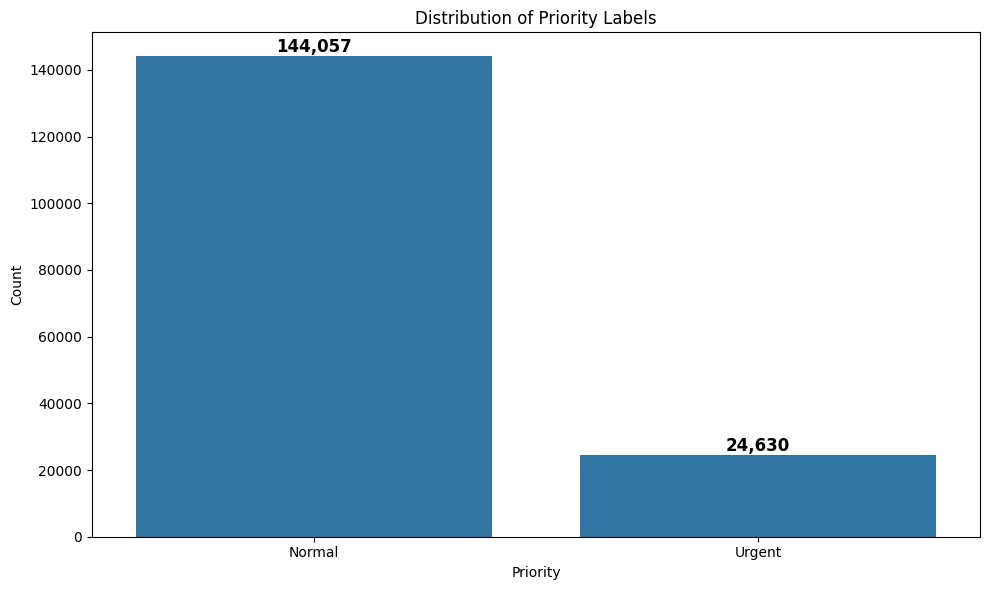

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns   
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='priority', data=sample)
plt.title('Distribution of Priority Labels')
plt.xlabel('Priority')
plt.ylabel('Count')
plt.xticks([0, 1], ['Normal', 'Urgent'])

# Add count annotations above each bar
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

### 6.2 Sentiment Distribution by Priority

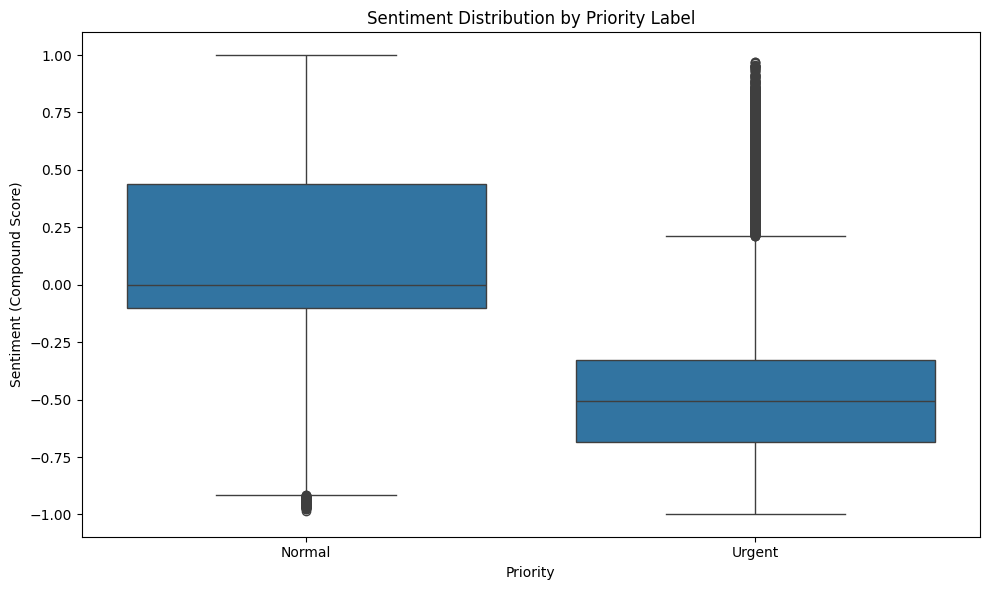

In [47]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='priority', y='sentiment', data=sample)
plt.title('Sentiment Distribution by Priority Label')
plt.xlabel('Priority')
plt.ylabel('Sentiment (Compound Score)')
plt.xticks([0, 1], ['Normal', 'Urgent'])
plt.tight_layout()
plt.show()

**Finding:** Clear sentiment separation between labels.
- Normal median: ~0.0 (neutral)
- Urgent median: ~-0.50 (clearly negative)
- Validates labeling function — urgent tweets are significantly more negative
- Normal outliers at -1.0 = false negatives (missed urgent tweets)

### 6.3 Confidence Score Distribution by Priority

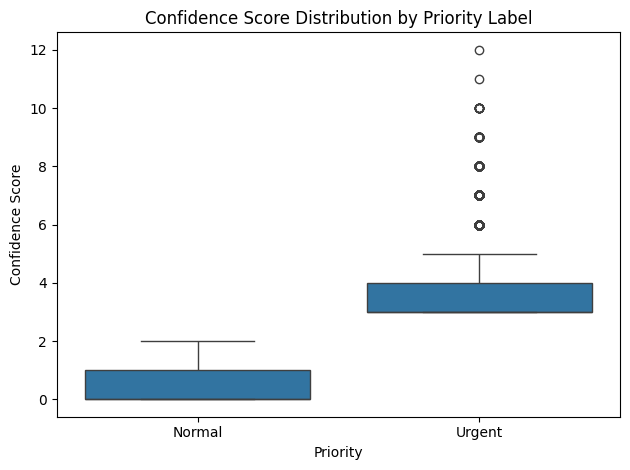

In [48]:
plt.figsize=(10, 6)
sns.boxplot(x='priority', y='confidence_score', data=sample)   
plt.title('Confidence Score Distribution by Priority Label')
plt.xlabel('Priority')
plt.ylabel('Confidence Score')
plt.xticks([0, 1], ['Normal', 'Urgent'])
plt.tight_layout()  
plt.show()

**Finding:** Confidence scores clearly separate Normal (0-2) from Urgent (3+).
Minimal overlap validates threshold=3 choice.
High-scoring tweets (8-12) triggered 4+ signals simultaneously — most unambiguous cases.

### 6.4 Tweet Length Distribution by Priority

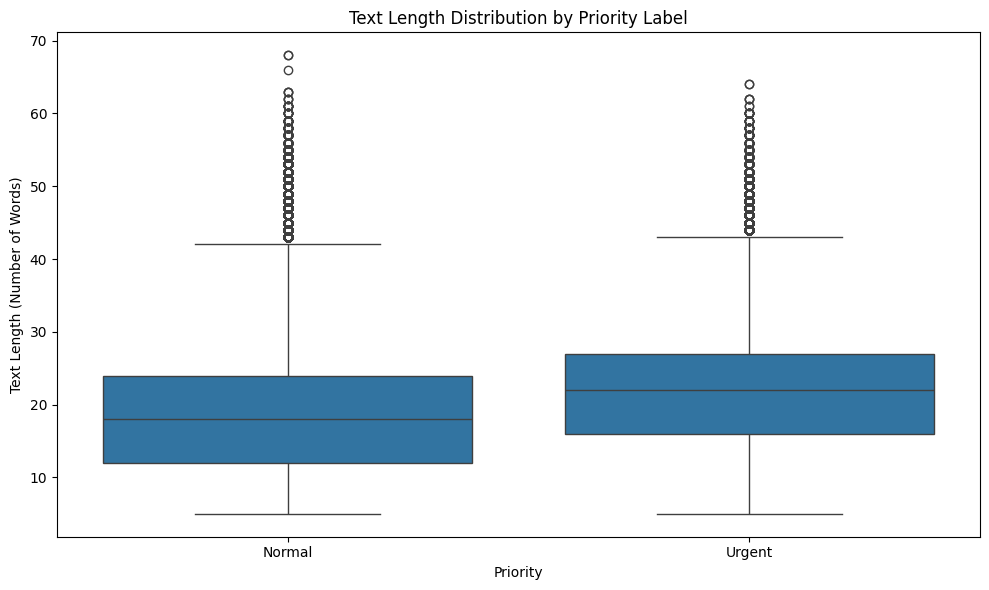

In [49]:
sample['text_length'] = sample['cleaned_text'].str.split().str.len()
plt.figure(figsize=(10, 6))
sns.boxplot(x='priority', y='text_length', data=sample)
plt.title('Text Length Distribution by Priority Label')
plt.xlabel('Priority')
plt.ylabel('Text Length (Number of Words)')
plt.xticks([0, 1], ['Normal', 'Urgent'])
plt.tight_layout()
plt.show()

**Finding:** Urgent tweets slightly longer (median ~22 words) vs Normal (~18 words).
Heavy overlap means text_length alone is weak predictor.
Include as one feature among many in ML model.

### 6.5 Top Words by Priority

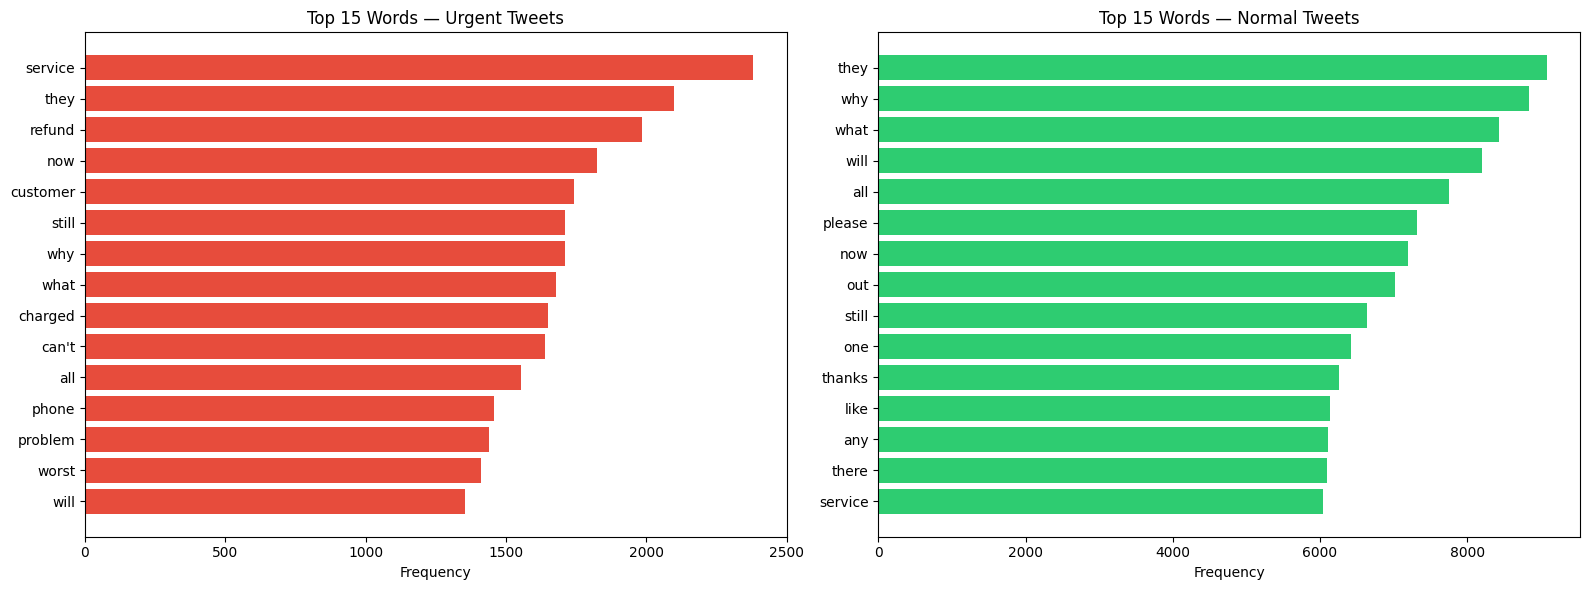

In [50]:
from collections import Counter

# Get top 15 words for each class
def get_top_words(df, priority, n=15):
    texts = df[df['priority']==priority]['cleaned_text']
    all_words = ' '.join(texts).split()
    # Remove very common words (stopwords)
    stopwords = {'i', 'my', 'the', 'a', 'to', 'and', 'is', 'it', 
                 'in', 'for', 'you', 'me', 'of', 'this', 'have',
                 'on', 'are', 'be', 'was', 'but', 'with', 'so',
                 'im', 'its', 'not', 'just', 'hi', 'hey', 'do',
                 'your', 'can', 'we', 'at', 'that', 'an', 'or',
                 'has', 'been', 'get', 'got', 'had', 'if', 'up',
                 'no', 'as', 'from', 'am', 'would', 'when', 'how'}
    filtered = [w for w in all_words if w not in stopwords and len(w) > 2]
    return Counter(filtered).most_common(n)

urgent_words = get_top_words(sample, 1)
normal_words = get_top_words(sample, 0)

# Plot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

words, counts = zip(*urgent_words)
ax1.barh(words, counts, color='#e74c3c')
ax1.set_title('Top 15 Words — Urgent Tweets')
ax1.set_xlabel('Frequency')
ax1.invert_yaxis()

words, counts = zip(*normal_words)
ax2.barh(words, counts, color='#2ecc71')
ax2.set_title('Top 15 Words — Normal Tweets')
ax2.set_xlabel('Frequency')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()